In [158]:
import pandas as pd
from v2_data_preparation import load_and_prepare_data, slice_by_dates

In [159]:
fp = '../data/raw/dataloggers/z6-28740(z6-28740)-Configuration 2-1781637377.3018472.csv'

In [160]:
df = pd.read_csv(
    fp,
    skiprows=2,
    index_col='Timestamps',
    parse_dates=True
)

In [161]:
df = df[' NDVI']

In [162]:
df_day = df.copy()
df_day = df_day.resample("30min").mean().dropna()

In [163]:
df_day

Timestamps
2024-11-08 12:30:00    0.069500
2024-11-08 13:00:00    0.069500
2024-11-08 13:30:00    0.070000
2024-11-08 14:00:00    0.070000
2024-11-08 14:30:00    0.071500
                         ...   
2026-06-16 12:00:00    0.094000
2026-06-16 12:30:00    0.094000
2026-06-16 13:00:00    0.094333
2026-06-16 13:30:00    0.095667
2026-06-16 14:00:00    0.096500
Name:  NDVI, Length: 14608, dtype: float64

In [164]:
df_day_mean = df_day.groupby(df_day.index.time).mean().round(3)

In [165]:
df_day_mean

00:00:00   -0.090
00:30:00   -0.265
01:00:00   -0.270
01:30:00   -0.266
02:00:00   -0.261
02:30:00   -0.260
03:00:00   -0.254
03:30:00   -0.258
04:00:00   -0.212
04:30:00   -0.035
05:00:00   -0.117
05:30:00   -0.144
06:00:00   -0.091
06:30:00    0.072
07:00:00    0.076
07:30:00    0.102
08:00:00    0.123
08:30:00    0.127
09:00:00    0.126
09:30:00    0.124
10:00:00    0.121
10:30:00    0.119
11:00:00    0.118
11:30:00    0.117
12:00:00    0.116
12:30:00    0.115
13:00:00    0.115
13:30:00    0.116
14:00:00    0.116
14:30:00    0.117
15:00:00    0.119
15:30:00    0.120
16:00:00    0.123
16:30:00    0.126
17:00:00    0.130
17:30:00    0.133
18:00:00    0.132
18:30:00    0.144
19:00:00    0.153
19:30:00    0.163
20:00:00    0.164
20:30:00    0.160
21:00:00    0.011
21:30:00    0.047
22:00:00   -0.149
22:30:00   -0.125
23:00:00   -0.106
23:30:00   -0.098
Name:  NDVI, dtype: float64

In [166]:
df_day_clean = df_day_mean.clip(lower=0)

<Axes: xlabel='time'>

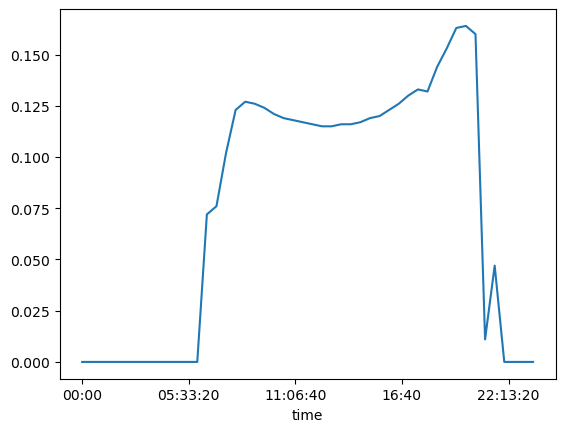

In [167]:
df_day_clean.plot()